In [101]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
from numba import prange

In [168]:
# Parameters
N_s   = 30
beta = 1.0
# global_inhibition = 0.2
# width = 0.2
v = 0.5
dt = 0.1
# L = 1000
sigma = 1.5
kappa = 20
u = 5.0

psi1 = -1
gamma1 = 5.0

psi2 = 2
gamma2 = 3.0

psi3 = np.pi * 3/2
gamma3 = 8.0

#targets = np.array([psi1, psi2])
targets = np.array([])

#gammas = np.array([gamma1, gamma2])
gammas = np.array([])




In [162]:
#Helper functions
def plot_ring_cartesian(z, theta, name):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot(theta, z, color='blue')

    ax.set_xlim(-np.pi, np.pi)
    ax.set_xticks([-np.pi, -3, -np.pi/2, -2, -1, 0, 1, 2, np.pi/2, 3, np.pi])
    ax.set_xticklabels(['-π', '-3', '-π/2', '-2', '-1', '0', '1', '2', 'π/2', '3', 'π'])
    ax.set_ylim(0, 2.0)
    ax.set_title(f'Firing rate of {name} around the ring')
    plt.tight_layout()
    plt.show()

def plot_multiple_ring_cartesian(u_vals, z_vals, theta, name):
    fig, ax = plt.subplots(figsize=(6, 6))
    colors = plt.cm.viridis(np.linspace(0, 1, len(z_vals)))

    for i in range(len(z_vals)):
        if i == 0:
            ax.plot(theta, z_vals[i], color='red', label=f'u_critical = {u_vals[i]}') # for u_crit
        else:    
            ax.plot(theta, z_vals[i], color=colors[i], label=f'u = {u_vals[i]}')

    ax.set_xlim(-np.pi, np.pi)
    ax.set_xticks([-np.pi, -3, -np.pi/2, -2, -1, 0, 1, 2, np.pi/2, 3, np.pi])
    ax.set_xticklabels(['-π', '-3', '-π/2', '-2', '-1', '0', '1', '2', 'π/2', '3', 'π'])
    ax.set_ylim(0, 2.0)
    ax.set_title(f'Firing rate of {name} around the ring')
    ax.legend()
    plt.tight_layout()
    plt.show()
    
def plot_ring_polar(z, theta, name):
    firing_rate  = np.maximum(0, z)
    theta_closed = np.append(theta, theta[0])
    fr_closed    = np.append(firing_rate, firing_rate[0])

    vel_vec   = find_vel_avg(theta, z)
    goal_angle = np.arctan2(vel_vec[1], vel_vec[0])
    arrow_r   = 1.5
    
    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={'projection': 'polar'})
    ax.fill_between(theta_closed, 0, fr_closed, alpha=0.4, color='blue')
    ax.plot(theta_closed, fr_closed, color='blue', linewidth=1.5)
    ax.annotate("", xy=(goal_angle, arrow_r), xytext=(goal_angle, 0),
                arrowprops=dict(arrowstyle="-|>", color='red', lw=2))
    ax.set_ylim(0, 2)
    ax.set_title(f'Firing rate of {name} around the ring')
    ax.set_theta_zero_location('E')
    ax.set_theta_direction(1)
    ax.set_xlim(-np.pi, np.pi)
    ax.set_xticks([-np.pi, -3, -np.pi/2, -2, -1, 0, 1, 2, np.pi/2, 3, np.pi])
    ax.set_xticklabels(['-π', '-3', '-π/2', '-2', '-1', '0', '1', '2', 'π/2', '3', 'π'])
    plt.tight_layout()
    plt.show()

def plot_z_vs_u(u_vals, z_vals):
    fig, ax = plt.subplots(figsize=(6, 6))
    pairs = sorted(zip(u_vals, z_vals))
    u_sorted, z_sorted = zip(*pairs)
    ax.plot(u_sorted, z_sorted, color='blue')
    ax.plot(u_vals, z_vals, color='blue')


    ax.set_title(f'z_max vs u')
    plt.tight_layout()
    plt.show()


def find_vel_avg(angles, activations):
    actv = activations.copy()

    x = np.sum(actv * np.cos(angles))
    y = np.sum(actv * np.sin(angles))
    goal_angle = np.arctan2(y, x)
    return np.array([np.cos(goal_angle), np.sin(goal_angle)])
    
def rand_link_func(y, sigma, inv_sqrt_n):
    out = np.empty_like(y)
    for i in prange(y.size):
        out[i] = np.random.normal(0.0, sigma) * inv_sqrt_n

    return out

def wrap_around(a1, a2):
    return (((a1-a2) + np.pi) % (2*np.pi)) - np.pi

def max_abs_eigenvalue(M):
    eigenvalues = np.linalg.eigvals(M)
    return np.max(np.abs(eigenvalues))



In [163]:
#RAN Functions

def genetate_connection_matrix(theta, v):
    M = np.zeros((N_s, N_s))

    for i in range(N_s):
        for j in range(N_s):          
            angular_diff = np.abs(wrap_around(theta[i], theta[j]))
            M[i, j] = np.cos(np.pi * np.power((angular_diff/np.pi), v)) * (1/N_s)

    return M
_
def generate_sensory_input(num_nodes, thetas, kappa, target_angles, target_qualities):
    b   = np.zeros(num_nodes)

    for j in range(len(target_angles)):
        for i in range(num_nodes):
            angular_diff = wrap_around(thetas[i], target_angles[j])
            b[i] += np.exp(kappa * (np.cos(angular_diff) - 1.0)) * target_qualities[j]

    b *= (1/np.sqrt(N_s)) 
    return b

def generate_RAN_with_history(u_val, num_nodes, M, num_integrations, dt, sigma, beta, b, target_angles, target_qualities):
    # Static RAN run
    z      = np.zeros(num_nodes) 
    z_next = np.zeros(num_nodes)
    y      = np.zeros((num_integrations, num_nodes))
    

    for t in range(num_integrations):
        noise = rand_link_func(y[t], sigma * np.sqrt(dt), 1.0/np.sqrt(N_s))
        z = z + dt * (-z + np.tanh(u_val * (M @ z) + b - beta) - np.tanh(-beta) + noise) 
        y[t] = z

    return y

    


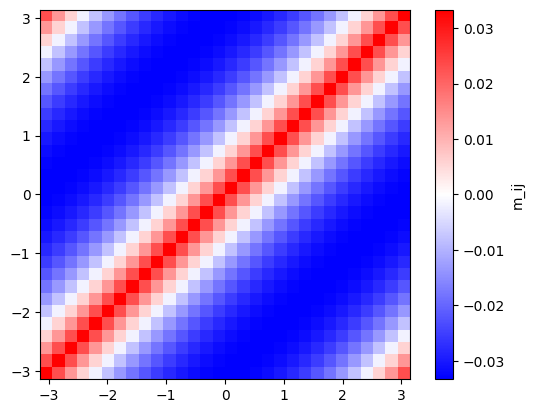

In [164]:
# Node positions and connectivity
#theta = np.array([2*np.pi*i/N_s for i in range(N_s)])
theta = np.linspace(-np.pi, np.pi, N_s, endpoint=False)
M = genetate_connection_matrix(theta, v)

plt.imshow(M, extent=[-np.pi, np.pi, -np.pi, np.pi], cmap='bwr',origin='lower')
plt.colorbar(label='m_ij')
plt.show()


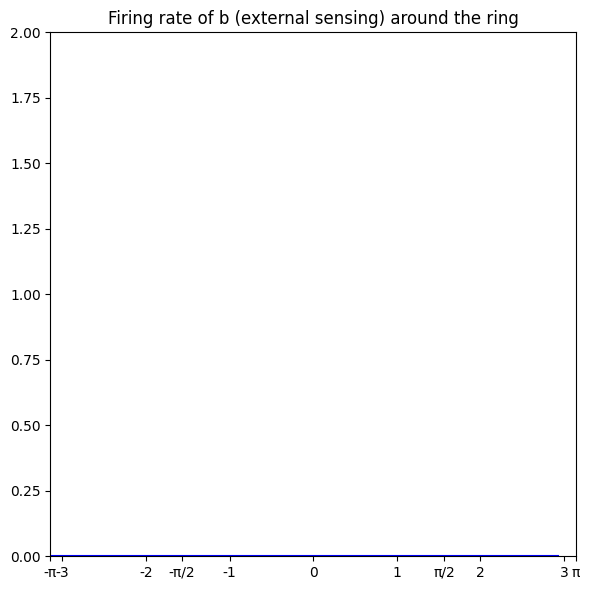

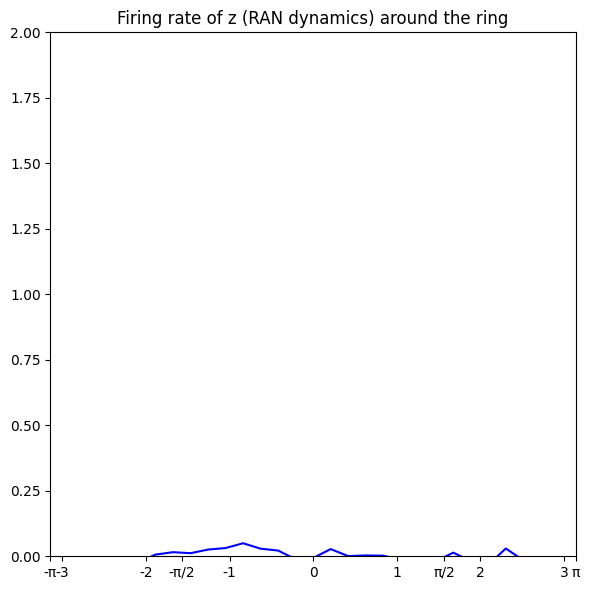

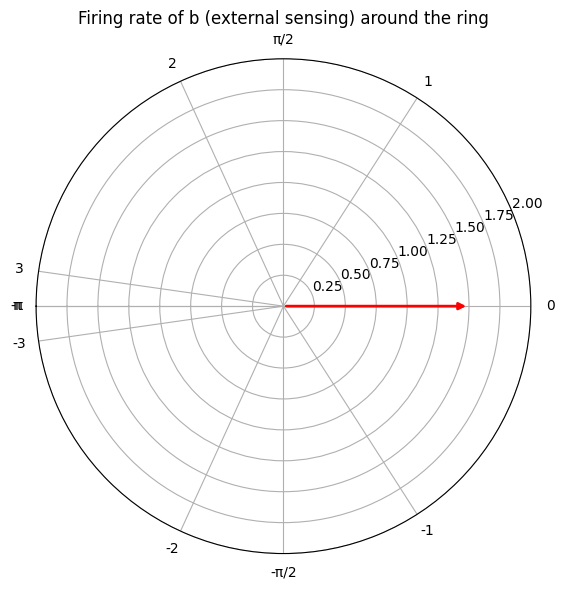

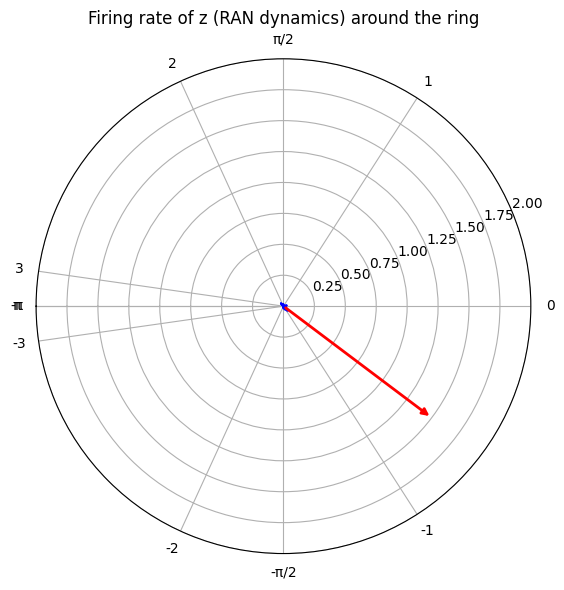

[]

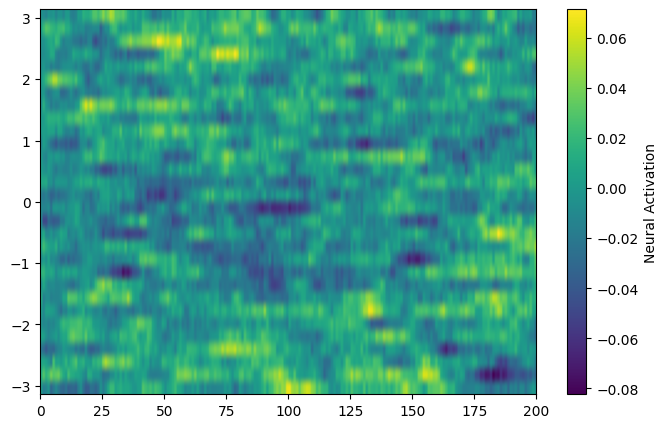

In [165]:
T = 200

b = generate_sensory_input(N_s, theta, kappa, targets, gammas)
y = generate_RAN_with_history(5.0, N_s, M, T, dt, sigma, beta, b, targets, gammas)
z_final = y[-1]

vel_vec_2D = find_vel_avg(theta, z_final)

plot_ring_cartesian(b, theta, "b (external sensing)")
plot_ring_cartesian(z_final, theta, "z (RAN dynamics)")
plot_ring_polar(b, theta, "b (external sensing)")
plot_ring_polar(z_final, theta, "z (RAN dynamics)")

plt.figure(figsize=(8,5))
plt.imshow(y.T, aspect='auto', origin='lower', cmap='viridis', extent=[0, T, -np.pi, np.pi])
plt.colorbar(label='Neural Activation')

plt.plot()


0.40345714830448554
5.902


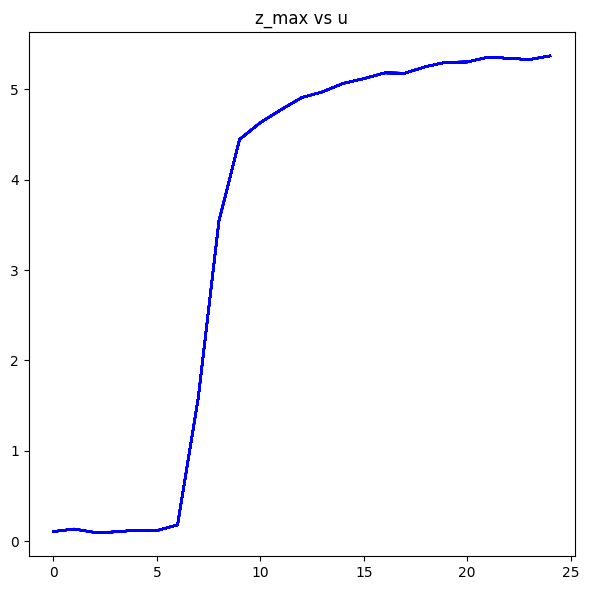

In [167]:
# Static RAN run, with multiple u's
u_crit = 1/(max_abs_eigenvalue(M) * np.power((1/np.cosh(beta)),2))
u_crit = round(u_crit, 3)

print(max_abs_eigenvalue(M))
print(u_crit)


#u_vals = [u_crit, 1.0, 3.0, 5.0, 5.85, 7.0, 10.0, 15.0, 25.0]
u_vals = []
for i in range(0,25):
    u_vals.append(float(i))

z_vals = []
z_vals_max = []
b = generate_sensory_input(N_s, theta, kappa, targets, gammas)

for num in range(len(u_vals)):
    T      = 200
    y = generate_RAN_with_history(u_vals[num], N_s, M, T, dt, sigma, beta, b, targets, gammas)
    
    y[-1] = np.linalg.norm(y[-1])
    z_vals.append(y[-1])
    z_vals_max.append(float(np.max(z)))
    
plot_z_vs_u(u_vals, z_vals)
